<h1>Wellen-Simulation</h1>

<h2>1D-Welle</h2>

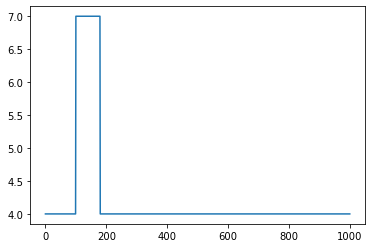

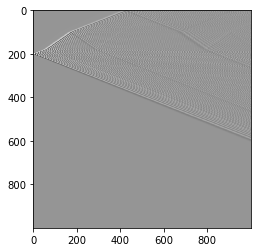

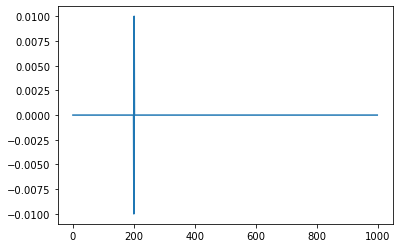

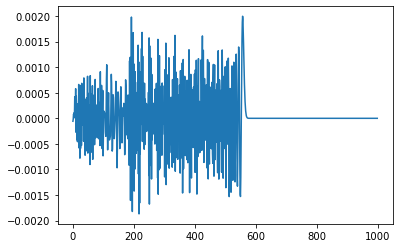

In [99]:
import numpy
import matplotlib.pyplot

def wellen_simulieren():
    for i in range(n_t-2):
        u[:,i+2] = future_wavefield(v, u[:,i],u[:,i+1])
    return u
    
def future_wavefield(v, past_wavefield, current_wavefield):
    cwe = numpy.concatenate(([current_wavefield[0]], current_wavefield, [current_wavefield[-1]]))
    past_wavefield[0] = current_wavefield[0]
    past_wavefield[-1] = current_wavefield[-1]
    #pwe = numpy.concatenate(([0], past_wavefield, [0]))
    #du_dx = 1/d_x * numpy.diff(current_wavefield_erweitert)
    #du_dx = 1/d_x * (cwe[1:]-cwe[:-1])
    #d2u_dx2 = 1/d_x * numpy.diff(du_dx)
    #d2u_dx2 = 1/(d_x*d_x) * (cwe[2:] - 2*cwe[1:-1] + cwe[:-2])
    #d2u_dt2 = 1/(d_x*d_x) * (pwe - 2*cwe[1:-1] + cwe[:-2])
    future_wavefield = 2*current_wavefield - past_wavefield + ((v*v*d_t*d_t)/(d_x*d_x))*(cwe[2:] - 2*cwe[1:-1] + cwe[:-2])
    
    return future_wavefield

n_x = 1000
n_t = 1000

d_x = 0.1
d_t = 0.01

v = 4*numpy.ones((n_x))
v[100:180] = 7
u = numpy.zeros((n_x, n_t))
u[201,1] = 0.01
u[200,1] = -0.01

u = wellen_simulieren()

matplotlib.pyplot.plot(v);
matplotlib.pyplot.show()
matplotlib.pyplot.imshow(u, cmap="Greys");
matplotlib.pyplot.show()
matplotlib.pyplot.plot(u[:,1]);
matplotlib.pyplot.show()
matplotlib.pyplot.plot(u[:,900]);


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '432x288', '-pix_fmt', 'rgba', '-r', '30', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-vcodec', 'libx264', '-y', 'wellen_animation.mp4']' returned non-zero exit status 255.

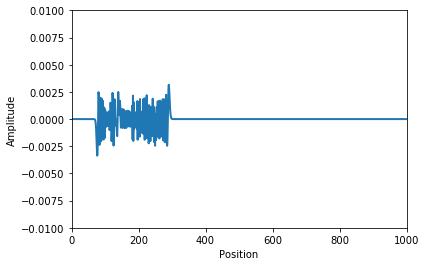

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def wellen_simulieren():
    for i in range(n_t-2):
        u[:, i+2] = future_wavefield(v, u[:, i], u[:, i+1])
    return u

def future_wavefield(v, past_wavefield, current_wavefield):
    cwe = np.concatenate(([current_wavefield[0]], current_wavefield, [current_wavefield[-1]]))
    past_wavefield[0] = current_wavefield[0]
    past_wavefield[-1] = current_wavefield[-1]
    
    future_wavefield = 2*current_wavefield - past_wavefield + ((v*v*d_t*d_t)/(d_x*d_x)) * (cwe[2:] - 2*cwe[1:-1] + cwe[:-2])
    
    return future_wavefield

n_x = 1000
n_t = 1000

d_x = 0.1
d_t = 0.01

v = 4 * np.ones((n_x))
v[100:180] = 7
u = np.zeros((n_x, n_t))
u[201, 1] = 0.01
u[200, 1] = -0.01

u = wellen_simulieren()

fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)
ax.set_ylim(-0.01, 0.01)
ax.set_xlim(0, n_x)
ax.set_xlabel('Position')
ax.set_ylabel('Amplitude')

def init():
    line.set_data([], [])
    return line,

def animate(i):
    y = u[:, i]
    line.set_data(np.arange(n_x), y)
    return line,

ani = FuncAnimation(fig, animate, frames=n_t, init_func=init, blit=True)
ani.save('wellen_animation.mp4', fps=30, extra_args=['-vcodec', 'libx264'])


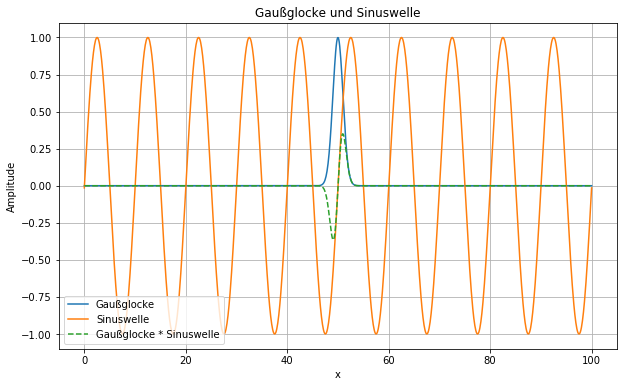

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter für die Gaußglocke und Sinuswelle
amplitude_gauss = 1.0
mu = 50       # Mittelwert der Gaußglocke
sigma = 1   # Standardabweichung der Gaußglocke
frequency = 0.1   # Frequenz der Sinuswelle
phase_shift = np.pi / 4-0.8  # Phasenverschiebung der Sinuswelle

# Erstellen des Numpy-Arrays
x = np.linspace(0, 100, 1000)  # x-Werte von 0 bis 100
gauss = amplitude_gauss * np.exp(-0.5 * ((x - mu) / sigma)**2)  # Gaußglocke
sin_wave = np.sin(2 * np.pi * frequency * x + phase_shift)  # Sinuswelle

# Multiplikation der beiden Arrays
result = gauss * sin_wave

# Plot der einzelnen Komponenten und des Ergebnisses
plt.figure(figsize=(10, 6))
plt.plot(x, gauss, label='Gaußglocke')
plt.plot(x, sin_wave, label='Sinuswelle')
plt.plot(x, result, label='Gaußglocke * Sinuswelle', linestyle='--')
plt.legend()
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.title('Gaußglocke und Sinuswelle')
plt.grid(True)
plt.show()

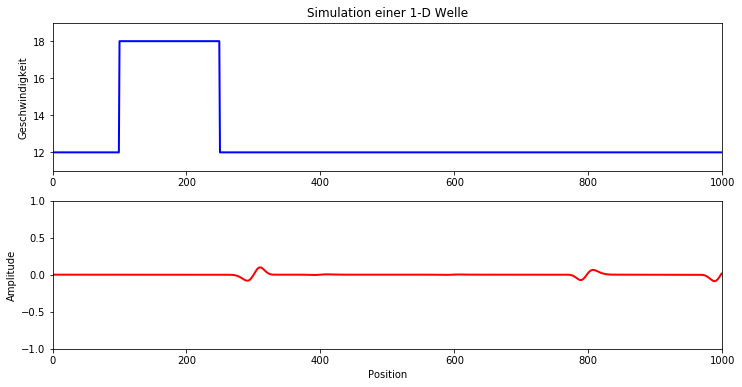

In [99]:
import numpy as np
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
n_x = 1000
n_t = 2000

d_x = 0.02
d_t = 0.001

# Anfangsbedingungen
amplitude_gauss = 1.0
mu = 50       # Mittelwert der Gaußglocke
sigma = 1   # Standardabweichung der Gaußglocke
frequency = 0.1   # Frequenz der Sinuswelle
phase_shift = np.pi / 4-0.8  # Phasenverschiebung der Sinuswelle
x = np.linspace(0, 100, n_x)  # x-Werte von 0 bis 100
gauss = amplitude_gauss * np.exp(-0.5 * ((x - mu) / sigma)**2)  # Gaußglocke
sin_wave = np.sin(2 * np.pi * frequency * x + phase_shift)  # Sinuswelle
start = 2*gauss * sin_wave

v = 12 * np.ones((n_x))
v[100:250] = 18

def wellen_simulieren():
    for i in range(n_t-2):
        u[:, i+2] = future_wavefield(v, u[:, i], u[:, i+1])
    return u

def future_wavefield(v, past_wavefield, current_wavefield):
    cwe = np.concatenate(([current_wavefield[0]], current_wavefield, [current_wavefield[-1]]))
    past_wavefield[0] = current_wavefield[0]
    past_wavefield[-1] = current_wavefield[-1]
    
    future_wavefield = 2*current_wavefield - past_wavefield + ((v*v*d_t*d_t)/(d_x*d_x)) * (cwe[2:] - 2*cwe[1:-1] + cwe[:-2])
    
    return future_wavefield



u = np.zeros((n_x, n_t))
u[:, 0] = start
u[:, 1] = start

u = wellen_simulieren()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

line1, = ax1.plot([], [], lw=2, color='blue', label='Amplitude')
line2, = ax2.plot([], [], lw=2, color='red', label='Wellen-Geschwindigkeit')
ax1.set_title("Simulation einer 1-D Welle")
ax1.set_ylim(numpy.min(v)-1, numpy.max(v)+1)
ax2.set_ylim(-1, 1)
ax1.set_xlim(0, n_x)
ax2.set_xlim(0, n_x)
ax2.set_xlabel('Position')
ax1.set_ylabel('Geschwindigkeit')
ax2.set_ylabel('Amplitude')

def init():
    line.set_data([], [])
    return line,

def animate(i):
    y_wave = u[:, i]
    y_velocity = v
    
    line1.set_data(np.arange(n_x), y_velocity)
    line2.set_data(np.arange(n_x), y_wave)
    
    return line1, line2

ani = FuncAnimation(fig, animate, frames=n_t, init_func=init, blit=True)
ani.save('wellen_animation4.mp4', fps=60, extra_args=['-vcodec', 'libx264'])

Parameter wie im Buch beschrieben:

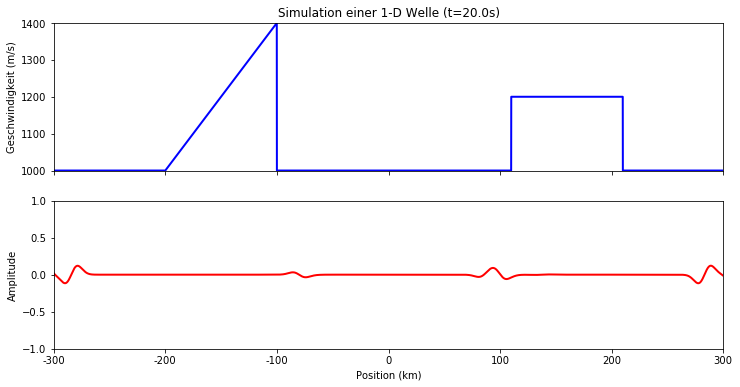

In [7]:
import numpy as np
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot

width = 600000 #m
d_x = 100 #m
time = 300 #s
d_t = 0.05

n_x = int(width/d_x)
n_t = int(time/d_t)


# Anfangsbedingungen
amplitude_gauss = 1.0
mu = 50       # Mittelwert der Gaußglocke
sigma = 1   # Standardabweichung der Gaußglocke
frequency = 0.1   # Frequenz der Sinuswelle
phase_shift = np.pi / 4-0.8  # Phasenverschiebung der Sinuswelle
x = np.linspace(0, 100, n_x)  # x-Werte von 0 bis 100
gauss = amplitude_gauss * np.exp(-0.5 * ((x - mu) / sigma)**2)  # Gaußglocke
sin_wave = np.sin(2 * np.pi * frequency * x + phase_shift)  # Sinuswelle
start = 2*gauss * sin_wave

v = 1000 * np.ones((n_x))
v[-1900:-900] = 1200
v[1000:2000] = numpy.linspace(1000,1400,1000)

def wellen_simulieren():
    for i in range(n_t-2):
        u[:, i+2] = future_wavefield(v, u[:, i], u[:, i+1])
    return u

def future_wavefield(v, past_wavefield, current_wavefield):
    cwe = np.concatenate(([current_wavefield[0]], current_wavefield, [current_wavefield[-1]]))
    past_wavefield[0] = current_wavefield[0]
    past_wavefield[-1] = current_wavefield[-1]
    
    future_wavefield = 2*current_wavefield - past_wavefield + ((v*v*d_t*d_t)/(d_x*d_x)) * (cwe[2:] - 2*cwe[1:-1] + cwe[:-2])
    
    return future_wavefield



u = np.zeros((n_x, n_t))
u[:, 0] = start
u[:, 1] = start

u = wellen_simulieren()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

line1, = ax1.plot([], [], lw=2, color='blue', label='Amplitude')
line2, = ax2.plot([], [], lw=2, color='red', label='Wellen-Geschwindigkeit')
ax1.set_title("Simulation einer 1-D Welle")
ax1.set_ylim(numpy.min(v)-1, numpy.max(v)+1)
ax2.set_ylim(-1, 1)
ax1.set_xlim(0, n_x)
ax2.set_xlim(0, n_x)
ax2.set_xlabel('Position (km)')
ax1.set_ylabel('Geschwindigkeit (m/s)')
ax2.set_ylabel('Amplitude')

# Set x-axis ticks and labels to show 0 to 600 meters
x_ticks = np.linspace(0, n_x, 7)  # Adjust the number of ticks as needed
x_ticklabels = np.linspace(-width/1000/2, width/1000/2, 7)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([])
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(['{:.0f}'.format(label) for label in x_ticklabels])


def init():
    line1.set_data([], [])
    line2.set_data([], [])
    return line1, line2

def animate(i):
    y_wave = u[:, i]
    y_velocity = v
    
    line1.set_data(np.arange(n_x), y_velocity)
    line2.set_data(np.arange(n_x), y_wave)
    ax1.set_title("Simulation einer 1-D Welle (t=" + str(numpy.round(i/time)) + "s)")
    
    return line1, line2

ani = FuncAnimation(fig, animate, frames=n_t, init_func=init, blit=True)
ani.save('wellen_animation7.mp4', fps=120, extra_args=['-vcodec', 'libx264'])

<h2>2D-Welle</h2>

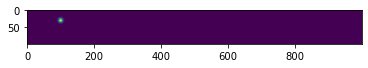

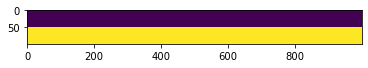

In [27]:
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot

heigth = 10
width = 100 #m
d_x = 0.1 #m
d_y = 0.1 #m
time = 50 #s
d_t = 0.01

n_x = int(width/d_x)
n_y = int(heigth/d_y)
n_t = int(time/d_t)


v = 1 * numpy.ones((n_y, n_x))
v[int(n_y/2):,:] = 4

def wellen_simulieren(u, v):
    for i in range(n_t-2):
        print(i+2, end='\r')
        u[:,:, i+2] = future_wavefield_vek(v, u[:, :, i], u[:, :, i+1])
    return u

def future_wavefield(v, u_p, current_wavefield): #u_p = u(k,l,i-1), u_c = u(k,l,i)
    future_wavefield = numpy.zeros((n_x, n_y))
    u_c = numpy.zeros((n_x+2, n_y+2))
    u_c[1:-1,1:-1] = current_wavefield #zum differenzieren erweitern, damit das ergebnis die selben dimensionen hat
    for k in range(n_x):
        for l in range(n_y):
            x = ((numpy.square(v[k,l])*numpy.square(d_t))/numpy.square(d_x))*(u_c[k+1,l] - 2*u_c[k,l] + u_c[k-1,l])
            y = ((numpy.square(v[k,l])*numpy.square(d_t))/numpy.square(d_y))*(u_c[k,l+1] - 2*u_c[k,l] + u_c[k,l-1])
            future_wavefield[k,l] = 2*u_c[k,l] - u_p[k,l] + x + y            
    return future_wavefield

def future_wavefield_vek(v, u_p, current_wavefield):
    u_c = numpy.pad(current_wavefield, ((1, 1), (1, 1)), mode='constant')  # Zero-padding

    x_diff = ((v * d_t / d_x) ** 2) * (u_c[2:, 1:-1] - 2 * u_c[1:-1, 1:-1] + u_c[:-2, 1:-1])
    y_diff = ((v * d_t / d_y) ** 2) * (u_c[1:-1, 2:] - 2 * u_c[1:-1, 1:-1] + u_c[1:-1, :-2])

    future_wavefield = 2 * u_c[1:-1, 1:-1] - u_p + x_diff + y_diff

    return future_wavefield


u = numpy.zeros((n_y, n_x, n_t))

amplitude_gauss = 20
mu = 50       # Mittelwert der Gaußglocke
sigma = 4   # Standardabweichung der Gaußglocke

x = numpy.linspace(0, 100, n_x)  # x-Werte von 0 bis 100
y = numpy.linspace(0, 100, n_y)  
# Erzeuge eine 2D-Gaußglocke
x, y = numpy.meshgrid(x, y)
gauss = amplitude_gauss * numpy.exp(-0.5 * ((x - mu+40) / (sigma-3.6))**2 - 0.5 * ((y - mu+20) / (sigma))**2)

u[:,:,0] = gauss
u[:,:,1] = gauss


u = wellen_simulieren(u, v)
matplotlib.pyplot.imshow(u[:,:,3])
matplotlib.pyplot.show()
matplotlib.pyplot.imshow(v)

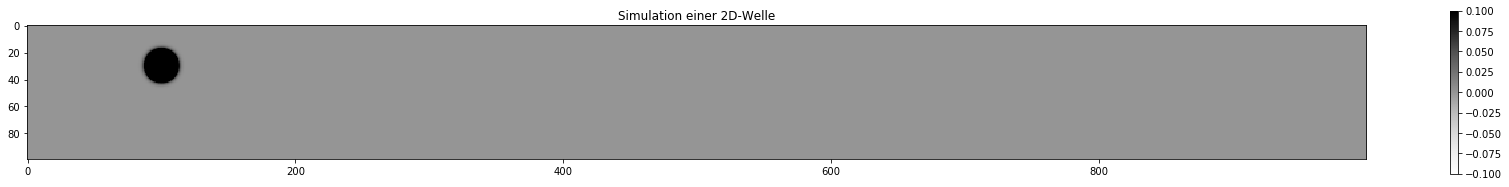

In [34]:
# Funktion für die Animation
def update(frame):
    print(frame, end='\r')
    im.set_array(u[:,:,frame])
    cbar.mappable.set_array(u[:, :, frame])
    return im,
 
# Erstelle das Figure-Objekt und die Axes-Objekte
fig, ax = plt.subplots(figsize=(30, 3))
im = ax.imshow(u[:,:,0], cmap='Greys')
ax.set_title("Simulation einer 2D-Welle")
cbar = plt.colorbar(im)
cbar.mappable.set_clim(-0.1, 0.1)

# Erstelle die Animation
ani = FuncAnimation(fig, update, frames=n_t, interval=50, blit=True)

# Zeige das Video an
plt.show()
ani.save('2D-Wellen_animation8.mp4', fps=int(1/d_t), extra_args=['-vcodec', 'libx264'])

Reflektion vermeiden (Outflow Boundary Condition):

1.0
400


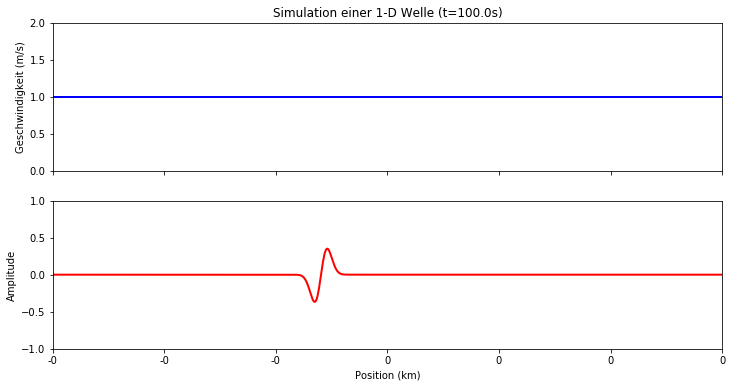

In [22]:
import numpy as np
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot

width = 10 #m
d_x = 0.01 #m
time = 4 #s
d_t = 0.01


n_x = int(width/d_x)
n_t = int(time/d_t)

# Anfangsbedingungen
amplitude_gauss = 1.0
mu = 80       # Mittelwert der Gaußglocke
sigma = 1   # Standardabweichung der Gaußglocke
frequency = 0.1   # Frequenz der Sinuswelle
phase_shift = np.pi / 4-0.8  # Phasenverschiebung der Sinuswelle
x = np.linspace(0, 100, n_x)  # x-Werte von 0 bis 100
gauss = amplitude_gauss * np.exp(-0.5 * ((x - mu) / sigma)**2)  # Gaußglocke
sin_wave = np.sin(2 * np.pi * frequency * x + phase_shift)  # Sinuswelle
start = 2*gauss * sin_wave

v = 1 * np.ones((n_x))
#v[-1900:-900] = 2200
#v[1000:2000] = numpy.linspace(2000,2400,1000)

print(v[-1]*d_t/d_x)
def wellen_simulieren(u, v):
    for i in range(n_t-2):
        u[:, i+2] = future_wavefield(v, u[:, i], u[:, i+1])
    return u

def future_wavefield(v, past_wavefield, current_wavefield): 
    new = 2*current_wavefield[1:-1] - past_wavefield[1:-1] + (((v[1:-1]**2)*(d_t**2))/(d_x*d_x)) * (current_wavefield[2:] - 2*current_wavefield[1:-1] + current_wavefield[0:-2])
    future_wavefield = np.concatenate(([new[0]], new, [new[-1]])) #offene Enden
    #future_wavefield = np.concatenate(([0], new, [0])) #geschlossene Enden
    future_wavefield[-1] = current_wavefield[-2]

    return future_wavefield



u = np.zeros((n_x, n_t))
u[:, 0] = start
u[:, 1] = start

u = wellen_simulieren(u, v)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

line1, = ax1.plot([], [], lw=2, color='blue', label='Amplitude')
line2, = ax2.plot([], [], lw=2, color='red', label='Wellen-Geschwindigkeit')
ax1.set_title("Simulation verschiedener Enden einer 1-D Welle")
ax1.set_ylim(numpy.min(v)-1, numpy.max(v)+1)
ax2.set_ylim(-1, 1)
ax1.set_xlim(0, n_x)
ax2.set_xlim(0, n_x)
ax2.set_xlabel('Position (km)')
ax1.set_ylabel('Geschwindigkeit (m/s)')
ax2.set_ylabel('Amplitude')

# Set x-axis ticks and labels to show 0 to 600 meters
x_ticks = np.linspace(0, n_x, 7)  # Adjust the number of ticks as needed
x_ticklabels = np.linspace(-width/1000/2, width/1000/2, 7)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([])
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(['{:.0f}'.format(label) for label in x_ticklabels])

print(n_t)
def init():
    line1.set_data([], [])
    line2.set_data([], [])
    return line1, line2

def animate(i):
    print(i, end='\r')
    y_wave = u[:, i]
    y_velocity = v
    
    line1.set_data(np.arange(n_x), y_velocity)
    line2.set_data(np.arange(n_x), y_wave)
    ax1.set_title("Simulation einer 1-D Welle (t=" + str(numpy.round(i/time)) + "s)")
    
    return line1, line2

ani = FuncAnimation(fig, animate, frames=n_t, init_func=init, blit=True)
ani.save('wellen_animation9.mp4', fps=120, extra_args=['-vcodec', 'libx264'])

0.3
666


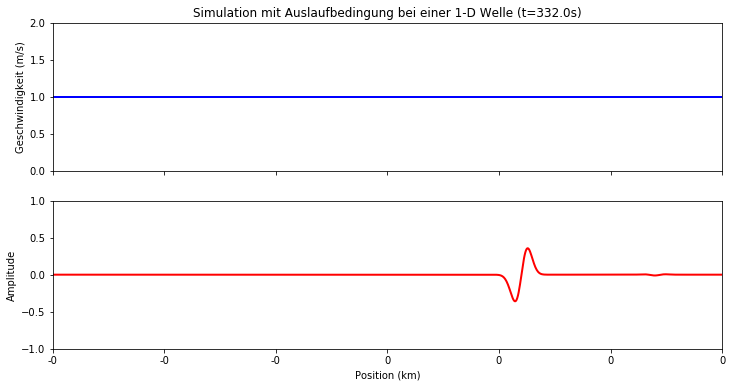

In [46]:
import numpy as np
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot

width = 10 #m
d_x = 0.01 #m
time = 2 #s
d_t = 0.003


n_x = int(width/d_x)
n_t = int(time/d_t)

# Anfangsbedingungen
amplitude_gauss = 1.0
mu = 90       # Mittelwert der Gaußglocke
sigma = 1   # Standardabweichung der Gaußglocke
frequency = 0.1   # Frequenz der Sinuswelle
phase_shift = np.pi / 4-0.8  # Phasenverschiebung der Sinuswelle
x = np.linspace(0, 100, n_x)  # x-Werte von 0 bis 100
gauss = amplitude_gauss * np.exp(-0.5 * ((x - mu) / sigma)**2)  # Gaußglocke
sin_wave = np.sin(2 * np.pi * frequency * x + phase_shift)  # Sinuswelle
start = 2*gauss * sin_wave

v = 1 * np.ones((n_x))
#v[-1900:-900] = 2200
#v[1000:2000] = numpy.linspace(2000,2400,1000)
print(numpy.max(v)*d_t/d_x)
if numpy.max(v)*d_t/d_x > 1:
    print(numpy.max(v)*d_t/d_x)
    print("v*d_t/d_x darf nicht größer als 1 sein. Sonst ist v schneller, als die Elemente nacheinander berechnet werden können.")
    
def wellen_simulieren(u, v):
    for i in range(n_t-2):
        u[:, i+2] = future_wavefield(v, u[:, i], u[:, i+1])
    return u

def future_wavefield(v, past_wavefield, current_wavefield): 
    new = 2*current_wavefield[1:-1] - past_wavefield[1:-1] + (((v[1:-1]**2)*(d_t**2))/(d_x*d_x)) * (current_wavefield[2:] - 2*current_wavefield[1:-1] + current_wavefield[0:-2])
    future_wavefield = np.concatenate(([new[0]], new, [new[-1]])) #offene Enden
    #future_wavefield = np.concatenate(([0], new, [0])) #geschlossene Enden
    #future_wavefield[-1] = current_wavefield[-2] + (1-v[-1]*d_t/d_x)*(current_wavefield[-1]-current_wavefield[-2])
    future_wavefield[-1] = current_wavefield[-1] - (v[-2]*d_t/d_x)*(current_wavefield[-1]-current_wavefield[-2])

    return future_wavefield



u = np.zeros((n_x, n_t))
u[:, 0] = start
u[:, 1] = start

u = wellen_simulieren(u, v)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

line1, = ax1.plot([], [], lw=2, color='blue', label='Amplitude')
line2, = ax2.plot([], [], lw=2, color='red', label='Wellen-Geschwindigkeit')
ax1.set_title("Simulation mit Auslaufbedingung bei einer 1-D Welle")
ax1.set_ylim(numpy.min(v)-1, numpy.max(v)+1)
ax2.set_ylim(-1, 1)
ax1.set_xlim(0, n_x)
ax2.set_xlim(0, n_x)
ax2.set_xlabel('Position (km)')
ax1.set_ylabel('Geschwindigkeit (m/s)')
ax2.set_ylabel('Amplitude')

# Set x-axis ticks and labels to show 0 to 600 meters
x_ticks = np.linspace(0, n_x, 7)  # Adjust the number of ticks as needed
x_ticklabels = np.linspace(-width/1000/2, width/1000/2, 7)
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([])
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(['{:.0f}'.format(label) for label in x_ticklabels])

print(n_t)
def init():
    line1.set_data([], [])
    line2.set_data([], [])
    return line1, line2

def animate(i):
    print(i, end='\r')
    y_wave = u[:, i]
    y_velocity = v
    
    line1.set_data(np.arange(n_x), y_velocity)
    line2.set_data(np.arange(n_x), y_wave)
    ax1.set_title("Simulation mit Auslaufbedingung bei einer 1-D Welle (t=" + str(numpy.round(i/time)) + "s)")
    
    return line1, line2

ani = FuncAnimation(fig, animate, frames=n_t, init_func=init, blit=True)
ani.save('wellen_animation10.mp4', fps=120, extra_args=['-vcodec', 'libx264'])

0.6


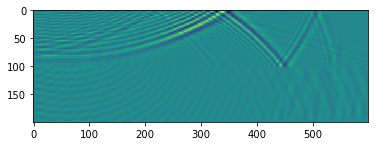

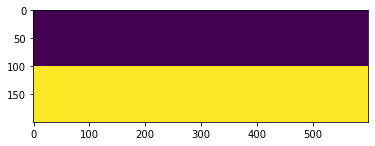

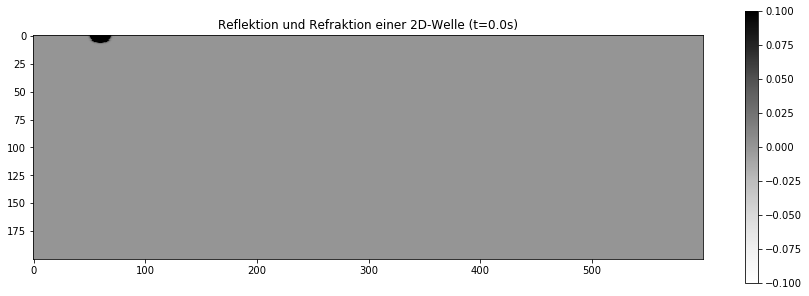

In [103]:
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot

heigth = 200
width = 600 #m
d_x = 1 #m
d_y = 1 #m
time = 0.5 #s
d_t = 0.0002

n_x = int(width/d_x)
n_y = int(heigth/d_y)
n_t = int(time/d_t)


v = 1000 * numpy.ones((n_y, n_x))
v[int(n_y/2):,:] = 3000

print(numpy.max(v)*d_t/d_x)
if numpy.max(v)*d_t/d_x > 1:
    print(numpy.max(v)*d_t/d_x)
    print("v*d_t/d_x darf nicht größer als 1 sein. Sonst ist v schneller, als die Elemente nacheinander berechnet werden können.")

def wellen_simulieren(u, v):
    for i in range(n_t-2):
        print(str(i+2)+" von "+str(n_t), end='\r')
        u[:,:, i+2] = future_wavefield_vek(v, u[:, :, i], u[:, :, i+1])
    return u

def future_wavefield(v, u_p, current_wavefield): #u_p = u(k,l,i-1), u_c = u(k,l,i)
    future_wavefield = numpy.zeros((n_x, n_y))
    u_c = numpy.zeros((n_x+2, n_y+2))
    u_c[1:-1,1:-1] = current_wavefield #zum differenzieren erweitern, damit das ergebnis die selben dimensionen hat
    for k in range(n_x):
        for l in range(n_y):
            x = ((numpy.square(v[k,l])*numpy.square(d_t))/numpy.square(d_x))*(u_c[k+1,l] - 2*u_c[k,l] + u_c[k-1,l])
            y = ((numpy.square(v[k,l])*numpy.square(d_t))/numpy.square(d_y))*(u_c[k,l+1] - 2*u_c[k,l] + u_c[k,l-1])
            future_wavefield[k,l] = 2*u_c[k,l] - u_p[k,l] + x + y            
    return future_wavefield

def future_wavefield_vek(v, u_p, c_w):
    u_c = numpy.pad(c_w, ((1, 1), (1, 1)), mode='constant')  # Zero-padding

    x_diff = ((v * d_t / d_x) ** 2) * (u_c[2:, 1:-1] - 2 * u_c[1:-1, 1:-1] + u_c[:-2, 1:-1])
    y_diff = ((v * d_t / d_y) ** 2) * (u_c[1:-1, 2:] - 2 * u_c[1:-1, 1:-1] + u_c[1:-1, :-2])

    future_wavefield = 2 * u_c[1:-1, 1:-1] - u_p + x_diff + y_diff
    
    future_wavefield[:,-1] = c_w[:,-1] - (v[:,-2]*d_t/d_x)*(c_w[:,-1]-c_w[:,-2])
    #future_wavefield[0,:] = c_w[0,:] - (v[1,:]*d_t/d_x)*(c_w[0,:]-c_w[1,:])
    future_wavefield[:,0] = c_w[:,0] - (v[:,1]*d_t/d_x)*(c_w[:,0]-c_w[:,1])
    future_wavefield[-1,:] = c_w[-1,:] - (v[-2,:]*d_t/d_x)*(c_w[-1,:]-c_w[-2,:])

    return future_wavefield


u = numpy.zeros((n_y, n_x, n_t))

amplitude_gauss = 10
mu = 50       # Mittelwert der Gaußglocke
sigma = 1   # Standardabweichung der Gaußglocke

x = numpy.linspace(0, 100, n_x)  # x-Werte von 0 bis 100
y = numpy.linspace(0, 100, n_y)  
# Erzeuge eine 2D-Gaußglocke
x, y = numpy.meshgrid(x, y)
gauss = amplitude_gauss * numpy.exp(-0.5 * ((x - mu+40) / (sigma-1.5))**2 - 0.5 * ((y ) / (sigma))**2)

u[:,:,0] = gauss
u[:,:,1] = gauss


u = wellen_simulieren(u, v)
matplotlib.pyplot.imshow(u[:,:,-1])
matplotlib.pyplot.show()
matplotlib.pyplot.imshow(v)

# Funktion für die Animation
def update(frame):
    print(frame, end='\r')
    im.set_array(u[:,:,frame])
    cbar.mappable.set_array(u[:, :, frame])
    cbar.mappable.set_clim(-0.1,0.1)
    ax.set_title("Reflektion und Refraktion einer 2D-Welle (t=" + str(numpy.round(frame/n_t, 2)) + "s)")
    return im,
 
# Erstelle das Figure-Objekt und die Axes-Objekte
fig, ax = plt.subplots(figsize=(15, 5))
im = ax.imshow(u[:,:,-1], cmap='Greys')
cbar = plt.colorbar(im)

# Erstelle die Animation
ani = FuncAnimation(fig, update, frames=n_t, interval=50, blit=True)

# Zeige das Video an
plt.show()
ani.save('2D-Wellen_animation16.mp4', fps=120, extra_args=['-vcodec', 'libx264'])

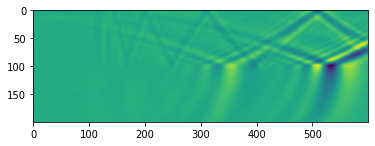

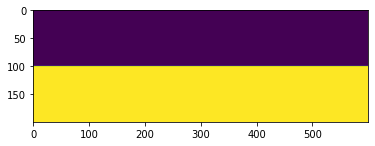

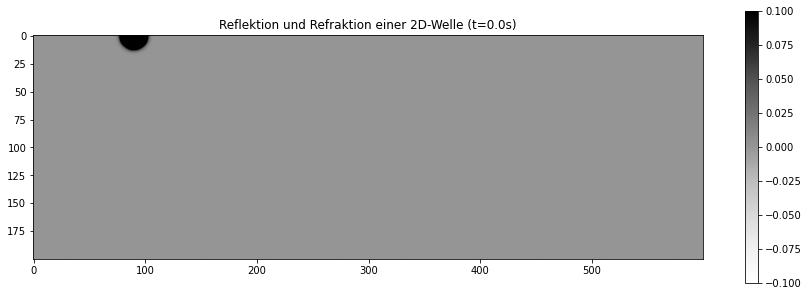

In [5]:
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot
import wellen_simulation

heigth = 200
width = 600 #m
d_x = 1 #m
d_y = 1 #m
time = 1 #s
d_t = 0.0002

n_x = int(width/d_x)
n_y = int(heigth/d_y)
n_t = int(time/d_t)
seitenverhältnis = n_y/n_x


v = 1000 * numpy.ones((n_y, n_x))
v[int(n_y/2):,:] = 3000

u = numpy.zeros((n_y, n_x, n_t))

gauss = wellen_simulation.point_source(amplitude_gauss=10, mu_x=0.15, mu_y=0, sigma=0.007, n_x=n_x, n_y=n_y)
u[:, :, 0] = gauss
u[:, :, 1] = gauss


u = wellen_simulation.wellen_simulieren(u, v, n_t, d_t, d_x, d_y)
matplotlib.pyplot.imshow(u[:,:,-1])
matplotlib.pyplot.show()
matplotlib.pyplot.imshow(v)

# Funktion für die Animation
def update(frame):
    print(frame, end='\r')
    im.set_array(u[:,:,frame])
    cbar.mappable.set_array(u[:, :, frame])
    cbar.mappable.set_clim(-0.1,0.1)
    ax.set_title("Reflektion und Refraktion einer 2D-Welle (t=" + str(numpy.round(frame/n_t, 2)) + "s)")
    return im,
 
# Erstelle das Figure-Objekt und die Axes-Objekte
skalierung = 15
fig, ax = plt.subplots(figsize=(skalierung, skalierung*seitenverhältnis))
im = ax.imshow(u[:,:,-1], cmap='Greys')
cbar = plt.colorbar(im)

# Erstelle die Animation
ani = FuncAnimation(fig, update, frames=n_t, interval=50, blit=True)

# Zeige das Video an
plt.show()
ani.save('2D-Wellen_animation17.mp4', fps=120, extra_args=['-vcodec', 'libx264'])